In [6]:
from lcr.config import PROCESSED_DATA_DIR
import pandas as pd
contextual_queries = pd.read_json(PROCESSED_DATA_DIR / "polish_final_cluster_reparsed/merged/contextual_queries.jsonl", lines=True)
chunks = pd.read_json(PROCESSED_DATA_DIR / "polish_final_cluster_reparsed/merged/chunks.jsonl", lines=True)
chunks['doc_name'] = chunks['chunk_id'].apply(lambda x: x.split('_')[0])

queries = contextual_queries.merge(chunks, on=['chunk_id', 'chunk_idx'])
chunks.set_index('chunk_id', inplace=True)

def id_to_idx(chunk_id):
    return chunks.loc[chunk_id, 'chunk_idx']

queries['utilized_idx'] = queries['utilized_context_chunk_ids'].apply(lambda ccids: [id_to_idx(ccid) for ccid in ccids])

def get_max_diff(utilized_idxs: list[int], chunk_idx: int) -> int:
    return max(abs(utilized_idx - chunk_idx) for utilized_idx in utilized_idxs)
# max utilized idx
queries['max_utilized_diff_idx'] = queries[['utilized_idx', 'chunk_idx']].apply(lambda row: get_max_diff(row['utilized_idx'], row['chunk_idx']), axis=1)

print(f"Got max utilized diff idx for {len(queries)} queries")

Got max utilized diff idx for 300 queries


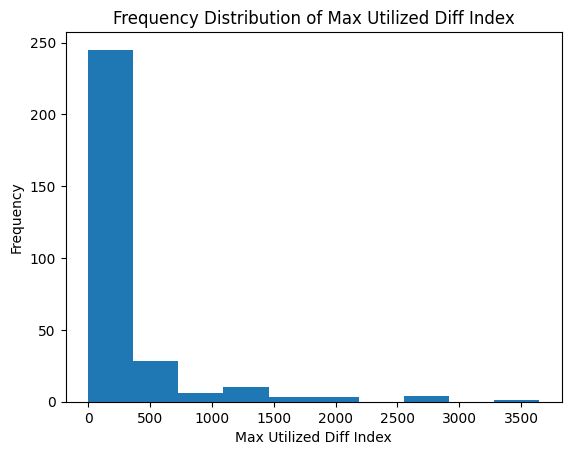

In [11]:
queries['max_utilized_diff_idx']
# do the frequency distribution of max_utilized_diff_idx
import matplotlib.pyplot as plt
plt.hist(queries['max_utilized_diff_idx'])
plt.xlabel('Max Utilized Diff Index')
plt.ylabel('Frequency')
plt.title('Frequency Distribution of Max Utilized Diff Index')
plt.show()

In [7]:
# compute the distance in tokens to the furthest utilized chunk (to its last token) (absolute distance)
# use tokens computed per qwen
import chunk
from transformers import AutoTokenizer
qwen_tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3-235B-A22B-Instruct-2507-FP8")


# first, get the amount of tokens in each chunk, put it into the dataframe
chunks['num_tokens'] = chunks['chunk'].apply(lambda text: len(qwen_tokenizer.tokenize(text)))
# then, ensure that the chunks are first sorted by the document name and then by the chunk index, so the computation can be carried out without splitting the dataframe by document
chunks.sort_values(by=['doc_name', 'chunk_idx'], inplace=True)
# compute the cumulative sum of tokens for each document, so we can easily compute the distance in tokens to the furthest utilized chunk
chunks['cumulative_tokens'] = chunks.groupby('doc_name')['num_tokens'].cumsum()
# now, we can compute the distance in tokens to the furthest utilized chunk for each query

def id_to_token_dist(chunk_id: str, utilized_id: str) -> int:
    target_chunk_cum = chunks.loc[chunk_id, 'cumulative_tokens']
    utilized_chunk_cum = chunks.loc[utilized_id, 'cumulative_tokens']
    diff = target_chunk_cum - utilized_chunk_cum
    if diff > 0:
        return abs(diff) + chunks.loc[utilized_id, 'num_tokens']  
    else:
        return abs(diff) + chunks.loc[chunk_id, 'num_tokens']

queries['tokens_to_context_chunks'] = queries[['chunk_id', 'utilized_context_chunk_ids']].apply(lambda row: [id_to_token_dist(row['chunk_id'], utilized_id) for utilized_id in row['utilized_context_chunk_ids']], axis=1)
# queries[['chunk_id', 'utilized_context_chunk_ids']].apply(lambda row: [id_to_token_dist(row['chunk_id'], utilized_id) for utilized_id in row['utilized_context_chunk_ids']], axis=1)

queries['max_tokens_to_context_chunks'] = queries['tokens_to_context_chunks'].apply(lambda token_dists: max(token_dists) if token_dists else 0)




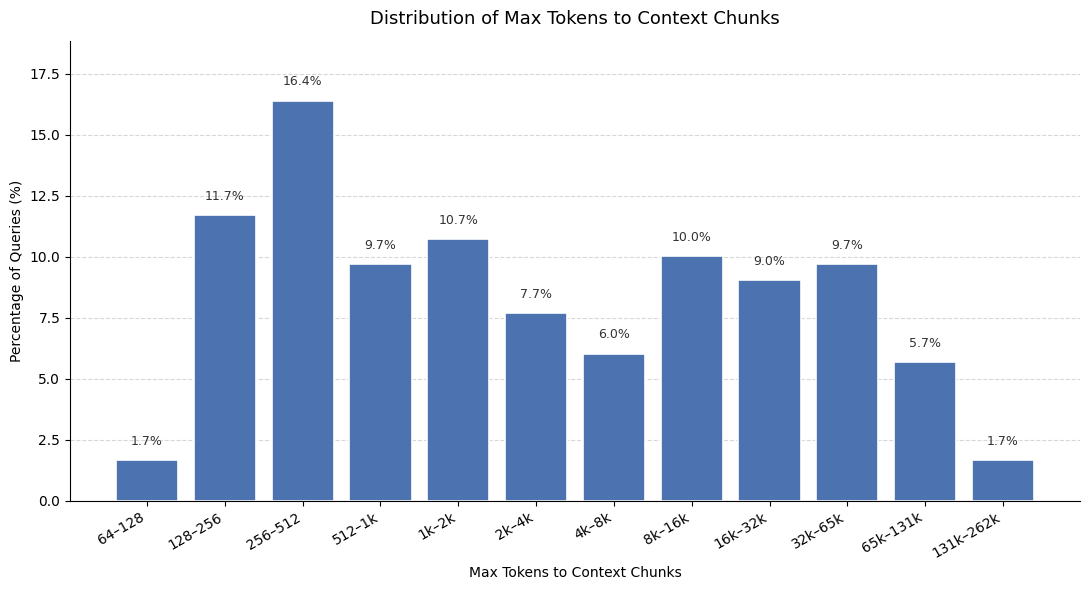

In [13]:
import numpy as np

bins = [2**i for i in range(6, 19)]  # 1, 2, 4, ..., 131072

def fmt_k(n):
    return f"{n//1000}k" if n >= 1000 else str(n)

bin_labels = [f"{fmt_k(lo)}–{fmt_k(hi)}" for lo, hi in zip(bins[:-1], bins[1:])]

counts, _ = np.histogram(queries['max_tokens_to_context_chunks'], bins=bins)
percentages = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(bin_labels))
bars = ax.bar(x, percentages, color='#4C72B0', edgecolor='white', linewidth=1.2)

for bar, pct in zip(bars, percentages):
    if pct > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{pct:.1f}%", ha='center', va='bottom', fontsize=9, color='#333')

ax.set_xticks(x)
ax.set_xticklabels(bin_labels, rotation=30, ha='right')
ax.set_xlabel('Max Tokens to Context Chunks')
ax.set_ylabel('Percentage of Queries (%)')
ax.set_title('Distribution of Max Tokens to Context Chunks', fontsize=13, pad=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
ax.set_ylim(0, max(percentages) * 1.15)

plt.tight_layout()
plt.show()

## DONE

In [8]:
# count how many queries per dataset
queries['dataset'] = queries['chunk_id'].apply(lambda x: x.split('_')[0])
dataset_counts = queries['dataset'].value_counts()
print(dataset_counts)

# pick a random sample of 5 from each dataset; if fewer than 5, take all. Print chunk_id
sampled_queries = queries.groupby('dataset').apply(lambda x: x.sample(n=min(4, len(x)), random_state=42)).reset_index(drop=True)
sampled_queries[['chunk_id', 'utilized_context_chunk_ids']]
print(sampled_queries['chunk_id'])

dataset
healthcarepublicfunds    96
police                   66
statefireservice         34
financingeducation       33
obligationtodefend       29
socialinsurancesystem    27
socialassistance         15
Name: count, dtype: int64
0         financingeducation_960
1         financingeducation_686
2         financingeducation_899
3         financingeducation_745
4      healthcarepublicfunds_638
5      healthcarepublicfunds_601
6     healthcarepublicfunds_3937
7      healthcarepublicfunds_970
8         obligationtodefend_340
9        obligationtodefend_2085
10       obligationtodefend_1789
11       obligationtodefend_2185
12                    police_368
13                    police_607
14                   police_1146
15                   police_2712
16          socialassistance_242
17          socialassistance_361
18         socialassistance_1179
19          socialassistance_848
20    socialinsurancesystem_1815
21     socialinsurancesystem_305
22    socialinsurancesystem_2007
23     soci